# XGBoost Classification

This notebook builds an XGBoost classifier to predict the **Category** of a product purchase. We mirror the structure of the Random Forest notebook ([09-random-forest.ipynb](09-random-forest.ipynb)) so results are directly comparable.

**Key constraints (same as prior models):**
- 1,625 unique product categories (extreme multi-class)
- Full 157K training set (32GB RAM, `tree_method='hist'`)
- Temporal train/test split (train ≤ 2021, test > 2021)

**Progress benchmarks:**
- Random Forest (tuned): ~5.5% accuracy
- Wide & Deep NN (tuned): ~6.4% accuracy

## 1. Data Loading and Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, make_scorer
)
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# Scorer with zero_division=0 prevents NaN when folds contain unseen classes
scorer = make_scorer(f1_score, average='weighted', zero_division=0)

print(f'XGBoost version: {xgb.__version__}')

XGBoost version: 3.2.0


In [2]:
# ── GPU CONFIG ────────────────────────────────────────────
# True  → uses RTX 4060 via CUDA (faster, needs 8GB VRAM)
# False → uses all CPU cores (n_jobs=-1), safe for everyone
USE_GPU = True

xgb_device = 'cuda' if USE_GPU else 'cpu'
xgb_njobs  = 1 if USE_GPU else -1

print(f'Device: {xgb_device} | n_jobs: {xgb_njobs}')
# ─────────────────────────────────────────────────────────

Device: cuda | n_jobs: 1


In [3]:
data = pd.read_csv('../data/cleaned_data.csv')
print(f'Dataset shape: {data.shape}')
print(f'Unique categories: {data["Category"].nunique()}')

Dataset shape: (157026, 156)
Unique categories: 1625


In [4]:
# Temporal train/test split
train = data[data['order_year'] <= 2021].copy()
test = data[data['order_year'] > 2021].copy()

# Drop test samples with categories unseen during training
train_cats = set(train['Category'].unique())
test_cats = set(test['Category'].unique())
unseen = test_cats - train_cats
test = test[~test['Category'].isin(unseen)]

print(f'Train: {len(train):,} | Test: {len(test):,} (removed {len(unseen)} unseen categories)')

Train: 113,655 | Test: 43,329 (removed 24 unseen categories)


In [5]:
# Drop non-predictive columns and split features/target
drop_cols = ['Title', 'ASIN/ISBN (Product Code)']

X_train = train.drop(['Category'] + drop_cols, axis=1)
y_train_raw = train['Category']

X_test = test.drop(['Category'] + drop_cols, axis=1)
y_test_raw = test['Category']

# XGBoost requires contiguous integer labels [0, num_class)
le = LabelEncoder()
le.fit(y_train_raw)
y_train = le.transform(y_train_raw)
y_test = le.transform(y_test_raw)

num_classes = len(le.classes_)
print(f'Features: {X_train.shape[1]} | Classes: {num_classes}')

Features: 153 | Classes: 1601


In [6]:
# Scale features (consistent with RF notebook — tree models don't require it but keeps comparability)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Use full training set — 32GB RAM handles 157K × 156 comfortably with tree_method='hist'
X_train_sub = X_train_scaled
y_train_sub = y_train

print(f'Train: {X_train_sub.shape} | Test: {X_test_scaled.shape}')

Train: (113655, 153) | Test: (43329, 153)


## 2. Baseline XGBoost

Using `tree_method='hist'` for memory efficiency. Device and parallelism are controlled by the `USE_GPU` flag above.

In [7]:
%%time

# XGBoost multi-class builds num_class trees per round.
# With 1,625 classes, n_estimators=50 produces ~81,250 trees — hist keeps this memory-efficient.
xgb_baseline = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=num_classes,
    tree_method='hist',
    device=xgb_device,
    n_jobs=xgb_njobs,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_baseline.fit(X_train_sub, y_train_sub)
print('Baseline XGBoost trained.')

Baseline XGBoost trained.
CPU times: total: 2min 45s
Wall time: 2min 55s


In [8]:
y_pred_baseline = xgb_baseline.predict(X_test_scaled)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_f1_macro = f1_score(y_test, y_pred_baseline, average='macro', zero_division=0)
baseline_f1_weighted = f1_score(y_test, y_pred_baseline, average='weighted', zero_division=0)

print(f'Baseline Accuracy:         {baseline_acc:.4f}')
print(f'Baseline F1 (macro):       {baseline_f1_macro:.4f}')
print(f'Baseline F1 (weighted):    {baseline_f1_weighted:.4f}')

Baseline Accuracy:         0.0746
Baseline F1 (macro):       0.0102
Baseline F1 (weighted):    0.0430


## 3. Feature Importance Analysis

In [9]:
feature_names = X_train.columns
importances = xgb_baseline.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('Top 20 most important features:')
feat_imp.head(20)

Top 20 most important features:


,Feature,Importance
102,state_Nebraska,0.023505
89,state_Idaho,0.022934
42,Shipping Address State_LA,0.019171
85,state_Delaware,0.018496
26,Shipping Address State_AL,0.018480
121,state_West Virginia,0.016345
146,"life-changes_Lost a job ,Moved place of residence",0.015724
72,Shipping Address State_WV,0.013853
151,"life-changes_Moved place of residence,Became p...",0.013790
144,"life-changes_Lost a job ,Divorce,Moved place o...",0.013335


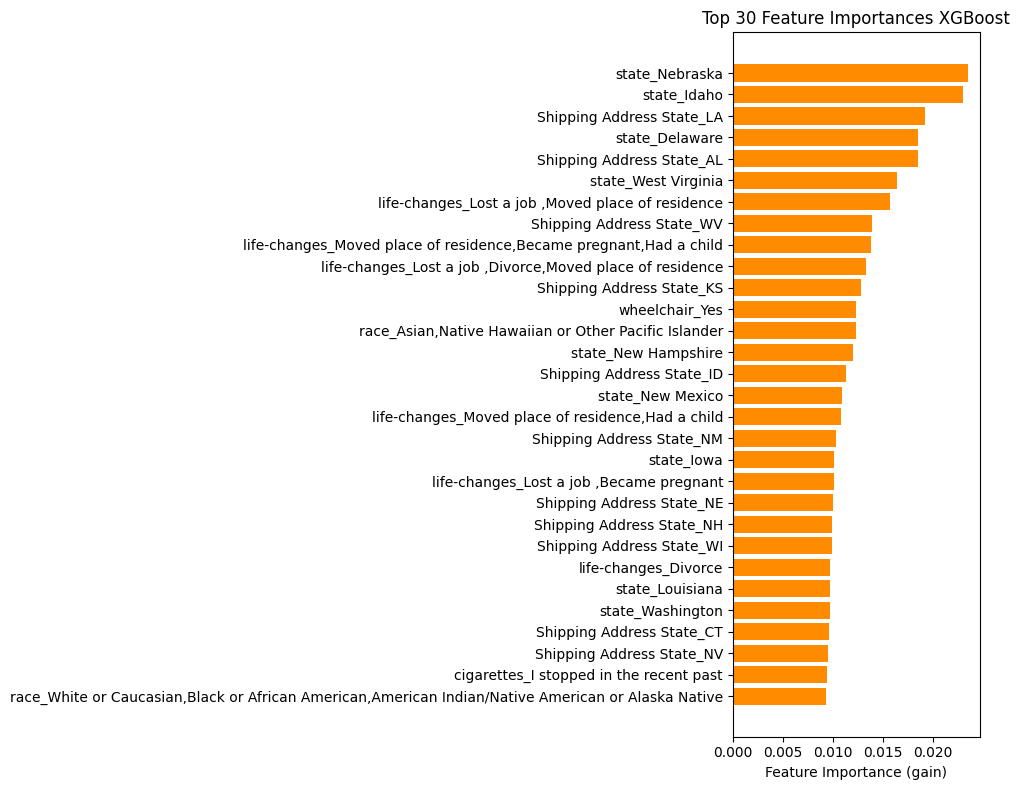

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 30
top_feats = feat_imp.head(top_n)

ax.barh(range(top_n), top_feats['Importance'].values, color='darkorange')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feats['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 30 Feature Importances XGBoost')
plt.tight_layout()
plt.show()

Features needed for 90% importance: 113 / 153
Features needed for 95% importance: 125 / 153


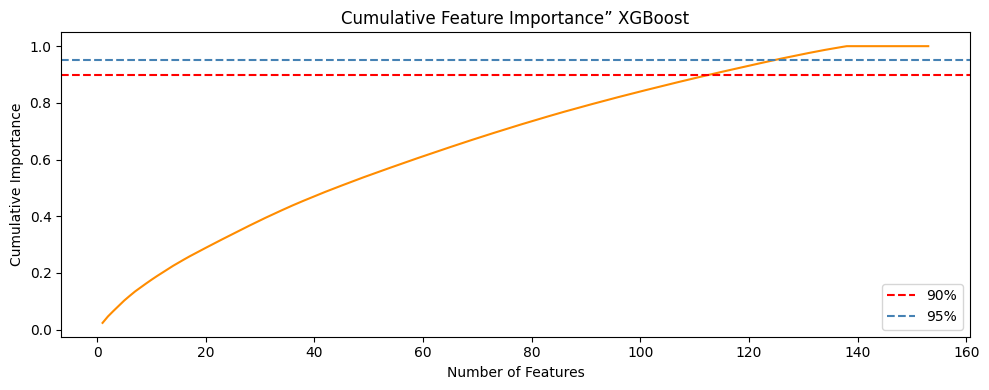

In [11]:
feat_imp['Cumulative'] = feat_imp['Importance'].cumsum()

n_90 = (feat_imp['Cumulative'] <= 0.90).sum() + 1
n_95 = (feat_imp['Cumulative'] <= 0.95).sum() + 1

print(f'Features needed for 90% importance: {n_90} / {len(feature_names)}')
print(f'Features needed for 95% importance: {n_95} / {len(feature_names)}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(feat_imp) + 1), feat_imp['Cumulative'].values, color='darkorange')
ax.axhline(y=0.90, color='r', linestyle='--', label='90%')
ax.axhline(y=0.95, color='steelblue', linestyle='--', label='95%')
ax.set_xlabel('Number of Features')
ax.set_ylabel('Cumulative Importance')
ax.set_title('Cumulative Feature Importance” XGBoost')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning

`RandomizedSearchCV` over XGBoost's key hyperparameters. Each candidate uses `n_jobs=-1` internally; the outer search runs sequentially (`n_jobs=1`) to avoid spawning nested parallelism.

In [12]:
%%time

# HP search on a 30K subsample filtered to classes with >= 4 samples.
# XGBoost 3.x requires every label in [0, num_class) to appear in the training
# fold. With 3-fold CV, filtering to >= 4 samples/class guarantees each training
# split (~20K rows) retains all classes — StratifiedKFold puts >=2 per training fold.
# device='cpu' avoids CUDA context issues inside sklearn's CV loop; GPU is still
# used for the full baseline and tuned models.
SEARCH_SIZE = 30_000
np.random.seed(42)
search_idx = np.random.choice(len(X_train_sub), SEARCH_SIZE, replace=False)
X_search_raw = X_train_sub[search_idx]
y_search_raw = y_train_sub[search_idx]

# Step 1: encode subsample labels
le_search = LabelEncoder()
y_search_encoded = le_search.fit_transform(y_search_raw)

# Step 2: filter to classes with >= 4 samples so all survive every training fold
search_series = pd.Series(y_search_encoded)
keep_classes = search_series.value_counts()[search_series.value_counts() >= 4].index
keep_mask = search_series.isin(keep_classes).values
X_search = X_search_raw[keep_mask]
y_search_filtered = y_search_encoded[keep_mask]

# Step 3: re-encode after filtering so labels are contiguous [0, n_filtered)
le_search2 = LabelEncoder()
y_search = le_search2.fit_transform(y_search_filtered)
num_classes_search = len(le_search2.classes_)
print(f'HP search: {len(X_search):,} rows, {num_classes_search} classes (filtered from 30K subsample)')

param_distributions = {
    'n_estimators': [30, 50, 100],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3]
}

xgb_search = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes_search,
    tree_method='hist',
    device='cpu',   # CPU avoids CUDA context issues in sklearn's CV loop
    n_jobs=-1,      # all cores for CPU search
    random_state=42,
    eval_metric='mlogloss'
)

random_search = RandomizedSearchCV(
    xgb_search,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring=scorer,
    random_state=42,
    n_jobs=1,
    verbose=2
)

random_search.fit(X_search, y_search)

print(f'\nBest score (F1 weighted): {random_search.best_score_:.4f}')
print(f'Best parameters: {random_search.best_params_}')

HP search: 29,151 rows, 948 classes (filtered from 30K subsample)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=4, min_child_weight=3, n_estimators=50, subsample=1.0; total time=  26.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=4, min_child_weight=3, n_estimators=50, subsample=1.0; total time=  28.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=4, min_child_weight=3, n_estimators=50, subsample=1.0; total time=  27.7s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, min_child_weight=3, n_estimators=50, subsample=1.0; total time=  29.7s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, min_child_weight=3, n_estimators=50, subsample=1.0; total time=  32.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, min_child_weight=3, n_estimators=50, subsample=1.0; total time=  32.4s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=5, min_c

In [13]:
search_results = pd.DataFrame(random_search.cv_results_)
search_results = search_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
search_results.sort_values('rank_test_score').head(10)

,params,mean_test_score,std_test_score,rank_test_score
8,"{'subsample': 1.0, 'n_estimators': 30, 'min_ch...",0.079874,0.002141,1
1,"{'subsample': 1.0, 'n_estimators': 50, 'min_ch...",0.077509,0.002464,2
6,"{'subsample': 0.8, 'n_estimators': 50, 'min_ch...",0.075274,0.001882,3
0,"{'subsample': 1.0, 'n_estimators': 50, 'min_ch...",0.071844,0.001514,4
3,"{'subsample': 1.0, 'n_estimators': 50, 'min_ch...",0.064010,0.001755,5
7,"{'subsample': 1.0, 'n_estimators': 30, 'min_ch...",0.060732,0.003061,6
4,"{'subsample': 1.0, 'n_estimators': 50, 'min_ch...",0.055085,0.001762,7
5,"{'subsample': 1.0, 'n_estimators': 50, 'min_ch...",0.046491,0.000384,8
9,"{'subsample': 1.0, 'n_estimators': 30, 'min_ch...",0.038785,0.001681,9
2,"{'subsample': 0.8, 'n_estimators': 30, 'min_ch...",0.038367,0.001130,10


## 5. Tuned Model 

In [14]:
%%time

best_params = random_search.best_params_
print(f'Training tuned model with: {best_params}')

xgb_tuned = xgb.XGBClassifier(
    **best_params,
    objective='multi:softprob',
    num_class=num_classes,
    tree_method='hist',
    device=xgb_device,
    n_jobs=xgb_njobs,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_tuned.fit(X_train_sub, y_train_sub)
print('Tuned model trained.')

Training tuned model with: {'subsample': 1.0, 'n_estimators': 30, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Tuned model trained.
CPU times: total: 1min 52s
Wall time: 1min 52s


In [15]:
y_pred_tuned = xgb_tuned.predict(X_test_scaled)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec_macro = precision_score(y_test, y_pred_tuned, average='macro', zero_division=0)
tuned_rec_macro = recall_score(y_test, y_pred_tuned, average='macro', zero_division=0)
tuned_f1_macro = f1_score(y_test, y_pred_tuned, average='macro', zero_division=0)
tuned_f1_weighted = f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0)

print('=== Tuned XGBoost Results ===')
print(f'Accuracy:             {tuned_acc:.4f}')
print(f'Precision (macro):    {tuned_prec_macro:.4f}')
print(f'Recall (macro):       {tuned_rec_macro:.4f}')
print(f'F1 Score (macro):     {tuned_f1_macro:.4f}')
print(f'F1 Score (weighted):  {tuned_f1_weighted:.4f}')

print(f'\n--- Comparison ---')
print(f'Baseline XGB accuracy: {baseline_acc:.4f}')
print(f'Tuned XGB accuracy:    {tuned_acc:.4f}')
print(f'Improvement:           {tuned_acc - baseline_acc:+.4f}')

=== Tuned XGBoost Results ===
Accuracy:             0.0778
Precision (macro):    0.0170
Recall (macro):       0.0134
F1 Score (macro):     0.0118
F1 Score (weighted):  0.0475

--- Comparison ---
Baseline XGB accuracy: 0.0746
Tuned XGB accuracy:    0.0778
Improvement:           +0.0033


In [ ]:
# Classification report for top 20 most frequent categories
y_test_series = pd.Series(y_test)
top_20_cats = y_test_series.value_counts().head(20).index.tolist()
mask = y_test_series.isin(top_20_cats)

print('Classification Report -” Top 20 Most Frequent Categories:')
print(classification_report(
    y_test[mask], y_pred_tuned[mask],
    labels=top_20_cats,
    zero_division=0
))

Classification Report â€” Top 20 Most Frequent Categories:
              precision    recall  f1-score   support

           2       0.27      0.67      0.38      1715
        1027       0.47      0.33      0.39       864
        1228       0.28      0.14      0.19       823
         967       0.36      0.21      0.26       694
         892       0.54      0.09      0.15       491
         998       0.25      0.04      0.08       423
         493       0.30      0.11      0.16       421
        1255       0.37      0.08      0.13       419
         721       0.22      0.04      0.06       371
        1231       0.31      0.25      0.28       370
        1250       0.48      0.09      0.15       358
         275       0.20      0.03      0.04       320
        1442       0.47      0.08      0.14       305
         586       0.48      0.08      0.14       289
        1537       0.58      0.05      0.09       285
        1033       0.19      0.03      0.05       275
         297       0.2

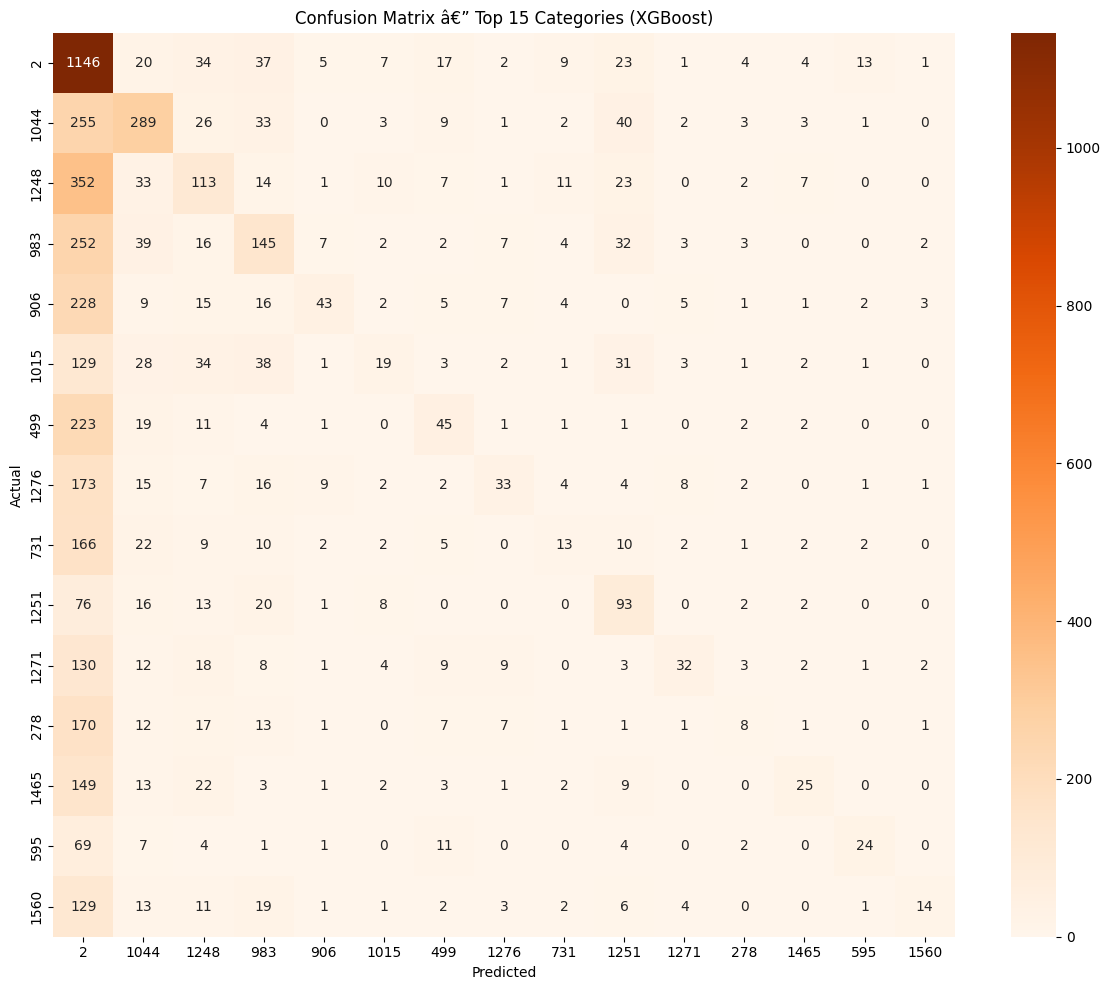

In [ ]:
# Confusion matrix for top 15 categories
top_15_cats = y_test_series.value_counts().head(15).index.tolist()
mask_15 = y_test_series.isin(top_15_cats)

# Map encoded labels back to original category IDs for readability
original_top_15 = le.inverse_transform(top_15_cats)

cm = confusion_matrix(y_test[mask_15], y_pred_tuned[mask_15], labels=top_15_cats)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=original_top_15, yticklabels=original_top_15, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix – Top 15 Categories (XGBoost)')
plt.tight_layout()
plt.show()

In [18]:
# Top 20 most frequent categories in test set
top_20_classes_xgb = y_test_series.value_counts().head(20).index.tolist()
n_classes_full_xgb = int(y_test.max()) + 1
cm_xgb_full = confusion_matrix(y_test, y_pred_tuned, labels=list(range(n_classes_full_xgb)))
total_xgb = len(y_test)

rows_xgb = []
for cls in top_20_classes_xgb:
    tp = int(cm_xgb_full[cls, cls])
    fp = int(cm_xgb_full[:, cls].sum() - tp)
    fn = int(cm_xgb_full[cls, :].sum() - tp)
    tn = int(total_xgb - tp - fp - fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
    cls_name = le.inverse_transform([cls])[0]
    rows_xgb.append({"Class": cls_name, "TP": tp, "TN": tn, "FP": fp, "FN": fn,
                     "Precision": round(prec,4), "Recall": round(rec,4), "F1": round(f1,4)})

metrics_xgb = pd.DataFrame(rows_xgb).set_index("Class")
print("Per-class TP / TN / FP / FN - XGBoost, Top 20 Most Frequent Categories:")
print(metrics_xgb.to_string())
print()
print(f"Overall Accuracy (all classes): {(y_test == y_pred_tuned).mean():.4f}")

from sklearn.metrics import f1_score
print()
print(f"F1 Macro    (unweighted avg over classes): {f1_score(y_test, y_pred_tuned, average='macro',    zero_division=0):.4f}")
print(f"F1 Weighted (weighted by class support):   {f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0):.4f}")
print(f"F1 Micro    (global TP / FP / FN totals):  {f1_score(y_test, y_pred_tuned, average='micro',    zero_division=0):.4f}")


Per-class TP / TN / FP / FN - XGBoost, Top 20 Most Frequent Categories:
         TP     TN     FP   FN  Precision  Recall      F1
Class                                                    
2      1146  25076  16538  569     0.0648  0.6682  0.1182
1044    289  40667   1798  575     0.1385  0.3345  0.1959
1248    113  40798   1708  710     0.0621  0.1373  0.0855
983     145  41231   1404  549     0.0936  0.2089  0.1293
906      43  42660    178  448     0.1946  0.0876  0.1208
1015     19  42471    435  404     0.0419  0.0449  0.0433
499      45  42286    622  376     0.0675  0.1069  0.0827
1276     33  42615    295  386     0.1006  0.0788  0.0884
731      13  42811    147  358     0.0813  0.0350  0.0490
1251     93  41477   1482  277     0.0590  0.2514  0.0956
1271     32  42814    157  326     0.1693  0.0894  0.1170
278       8  42814    195  312     0.0394  0.0250  0.0306
1465     25  42881    143  280     0.1488  0.0820  0.1057
595      24  42851    189  265     0.1127  0.0830  0.0956


## 6. Cross-Validation

In [19]:
%%time

train_df = pd.DataFrame(X_train_sub, columns=feature_names)
train_df['Category'] = y_train_sub

cat_counts = train_df['Category'].value_counts()
valid_cats = cat_counts[cat_counts >= 5].index
train_df_filtered = train_df[train_df['Category'].isin(valid_cats)]

le_cv = LabelEncoder()
X_cv = train_df_filtered.drop('Category', axis=1).values
y_cv = le_cv.fit_transform(train_df_filtered['Category'].values)
num_classes_cv = len(le_cv.classes_)

print(f'CV data: {len(X_cv):,} samples, {num_classes_cv} categories (filtered to >= 5 per class)')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv = xgb.XGBClassifier(
    **best_params,
    objective='multi:softprob',
    num_class=num_classes_cv,
    tree_method='hist',
    device=xgb_device,
    n_jobs=xgb_njobs,
    random_state=42,
    eval_metric='mlogloss'
)

cv_scores = cross_val_score(xgb_cv, X_cv, y_cv, cv=cv, scoring=scorer, n_jobs=1)

print(f'\nCV F1 (weighted) scores: {cv_scores}')
print(f'Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})')

CV data: 113,032 samples, 1317 categories (filtered to >= 5 per class)

CV F1 (weighted) scores: [0.10466418 0.1028849  0.10800833 0.10395887 0.10695512]
Mean: 0.1053 (+/- 0.0038)
CPU times: total: 6min 56s
Wall time: 6min 21s


In [20]:
cv_acc_scores = cross_val_score(xgb_cv, X_cv, y_cv, cv=cv, scoring='accuracy', n_jobs=1)

print(f'CV Accuracy scores: {cv_acc_scores}')
print(f'Mean: {cv_acc_scores.mean():.4f} (+/- {cv_acc_scores.std() * 2:.4f})')

CV Accuracy scores: [0.14278763 0.14194718 0.14562506 0.14235159 0.14478457]
Mean: 0.1435 (+/- 0.0029)


## 7. Summary

In [21]:
print('=' * 55)
print('          XGBOOST — RESULTS SUMMARY')
print('=' * 55)
print(f'  Dataset:              {data.shape[0]:,} samples, {X_train.shape[1]} features')
print(f'  Categories:           {num_classes}')
print(f'  Train size:           {len(y_train_sub):,}')
print(f'  Test set:             {len(y_test):,}')
print(f'')
print(f'  --- Baseline XGBoost ---')
print(f'  Accuracy:             {baseline_acc:.4f}')
print(f'  F1 (weighted):        {baseline_f1_weighted:.4f}')
print(f'')
print(f'  --- Tuned XGBoost ---')
print(f'  Best params:          {best_params}')
print(f'  Accuracy:             {tuned_acc:.4f}')
print(f'  Precision (macro):    {tuned_prec_macro:.4f}')
print(f'  Recall (macro):       {tuned_rec_macro:.4f}')
print(f'  F1 (macro):           {tuned_f1_macro:.4f}')
print(f'  F1 (weighted):        {tuned_f1_weighted:.4f}')
print(f'')
print(f'  --- Cross-Validation (5-fold, full train) ---')
print(f'  F1 (weighted):        {cv_scores.mean():.4f} +/- {cv_scores.std() * 2:.4f}')
print(f'  Accuracy:             {cv_acc_scores.mean():.4f} +/- {cv_acc_scores.std() * 2:.4f}')
print(f'')
print(f'  --- Model Comparison ---')
print(f'  Random Forest (tuned):    ~5.5% accuracy')
print(f'  Wide & Deep NN (tuned):   ~6.4% accuracy')
print(f'  XGBoost (tuned):          {tuned_acc*100:.1f}% accuracy')
print('=' * 55)

          XGBOOST — RESULTS SUMMARY
  Dataset:              157,026 samples, 153 features
  Categories:           1601
  Train size:           113,655
  Test set:             43,329

  --- Baseline XGBoost ---
  Accuracy:             0.0746
  F1 (weighted):        0.0430

  --- Tuned XGBoost ---
  Best params:          {'subsample': 1.0, 'n_estimators': 30, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
  Accuracy:             0.0778
  Precision (macro):    0.0170
  Recall (macro):       0.0134
  F1 (macro):           0.0118
  F1 (weighted):        0.0475

  --- Cross-Validation (5-fold, full train) ---
  F1 (weighted):        0.1053 +/- 0.0038
  Accuracy:             0.1435 +/- 0.0029

  --- Model Comparison ---
  Random Forest (tuned):    ~5.5% accuracy
  Wide & Deep NN (tuned):   ~6.4% accuracy
  XGBoost (tuned):          7.8% accuracy
